# Pre-proccessing

## Import Library

In [1]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

## Memuat Data

In [2]:
folder_dataset_bersih = 'Dataset_Fix'
varietas_durian = [f.name for f in os.scandir(folder_dataset_bersih) if f.is_dir()]
print(f"Kelas terdeteksi: {varietas_durian}\n")

data_mentah = []
label_citra = []

print("Memuat dataset citra asli...")
for varietas in varietas_durian:
    jalur_varietas = os.path.join(folder_dataset_bersih, varietas)
    
    for nama_file in tqdm(os.listdir(jalur_varietas), desc=varietas):
        jalur_file = os.path.join(jalur_varietas, nama_file)
        img = cv2.imread(jalur_file)
        
        if img is not None:
            # Menyimpan gambar asli secara mentah terlebih dahulu
            data_mentah.append(img)
            label_citra.append(varietas)

print(f"\nTotal gambar berhasil dimuat: {len(data_mentah)} citra")

Kelas terdeteksi: ['Bawor', 'DuriHitam', 'Monthong', 'MusangKing']

Memuat dataset citra asli...


MusangKing: 100%|██████████| 441/441 [00:11<00:00, 38.15it/s]


Total gambar berhasil dimuat: 1846 citra


## Resizing

In [3]:
data_citra_resized = []

print("Melakukan penyesuaian dimensi (Resizing) ke 224x224 piksel...")
for img in tqdm(data_mentah, desc="Resizing"):
    # Resizing gambar secara absolut
    img_resized = cv2.resize(img, (224, 224))
    
    # Konversi format ruang warna BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    data_citra_resized.append(img_rgb)

# Mengubah daftar menjadi larik matriks NumPy
X = np.array(data_citra_resized, dtype=np.float32)
print(f"\nBentuk matriks komputasi akhir (X): {X.shape}")

# MENGHEMAT MEMORI: Menghapus data mentah yang sudah tidak terpakai dari RAM
del data_mentah

Melakukan penyesuaian dimensi (Resizing) ke 224x224 piksel...


Resizing: 100%|██████████| 1846/1846 [00:01<00:00, 1181.09it/s]



Bentuk matriks komputasi akhir (X): (1846, 224, 224, 3)


## Labelling

In [4]:
print("Melakukan pelabelan kelas numerik...")

# Transformasi teks menjadi angka
encoder = LabelEncoder()
label_numerik = encoder.fit_transform(label_citra)

# Transformasi angka menjadi matriks kategorikal
y = to_categorical(label_numerik, num_classes=4)

print("\nHasil Pemetaan Kelas:")
for index, nama_kelas in enumerate(encoder.classes_):
    print(f"Kelas {nama_kelas} direpresentasikan sebagai indeks {index}")
    
print(f"Bentuk matriks label (y): {y.shape}")

Melakukan pelabelan kelas numerik...

Hasil Pemetaan Kelas:
Kelas Bawor direpresentasikan sebagai indeks 0
Kelas DuriHitam direpresentasikan sebagai indeks 1
Kelas Monthong direpresentasikan sebagai indeks 2
Kelas MusangKing direpresentasikan sebagai indeks 3
Bentuk matriks label (y): (1846, 4)


## Pembagian Proporsi Data (Splitting)

In [5]:
print("Membagi data: Pelatihan (70%), Validasi (15%), dan Pengujian (15%)...")

# Tahap 1: Memisahkan 15% untuk Pengujian
X_latih_valid, X_uji, y_latih_valid, y_uji = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Tahap 2: Memecah sisa 85% menjadi 70% Pelatihan dan 15% Validasi
X_latih, X_valid, y_latih, y_valid = train_test_split(
    X_latih_valid, y_latih_valid, test_size=(15/85), random_state=42, stratify=y_latih_valid
)

# Menampilkan hasil distribusi tiap kelas menggunakan penjumlahan matriks
kelas_label = encoder.classes_

print(f"\nDistribusi Data Pelatihan (Total {X_latih.shape} citra):")
for i, jumlah in enumerate(np.sum(y_latih, axis=0)):
    print(f" {kelas_label[i]}: {int(jumlah)} citra")

print(f"\nDistribusi Data Validasi (Total {X_latih.shape} citra):")
for i, jumlah in enumerate(np.sum(y_valid, axis=0)):
    print(f" {kelas_label[i]}: {int(jumlah)} citra")

print(f"\nDistribusi Data Pengujian (Total {X_uji.shape} citra):")
for i, jumlah in enumerate(np.sum(y_uji, axis=0)):
    print(f" {kelas_label[i]}: {int(jumlah)} citra")

Membagi data: Pelatihan (70%), Validasi (15%), dan Pengujian (15%)...

Distribusi Data Pelatihan (Total (1292, 224, 224, 3) citra):
 Bawor: 445 citra
 DuriHitam: 231 citra
 Monthong: 307 citra
 MusangKing: 309 citra

Distribusi Data Validasi (Total (1292, 224, 224, 3) citra):
 Bawor: 96 citra
 DuriHitam: 49 citra
 Monthong: 66 citra
 MusangKing: 66 citra

Distribusi Data Pengujian (Total (277, 224, 224, 3) citra):
 Bawor: 96 citra
 DuriHitam: 49 citra
 Monthong: 66 citra
 MusangKing: 66 citra


## Augmentasi

In [6]:
# 1. Generator Pelatihan (DENGAN efek augmentasi)
datagen_latih = ImageDataGenerator(
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.5, 1.5],
    fill_mode='nearest'
)

# 2. Generator Validasi dan Uji (MURNI, TANPA augmentasi)
datagen_valid_uji = ImageDataGenerator()

ukuran_batch = 16

# 3. Memasukkan matriks data ke dalam masing-masing generator
generator_latih = datagen_latih.flow(X_latih, y_latih, batch_size=ukuran_batch)

# shuffle=False sangat penting agar urutan data ujian tidak acak saat evaluasi akhir
generator_valid = datagen_valid_uji.flow(X_valid, y_valid, batch_size=ukuran_batch, shuffle=False)
generator_uji = datagen_valid_uji.flow(X_uji, y_uji, batch_size=ukuran_batch, shuffle=False)

print("\n=== STATUS GENERATOR DATA ===")
print(f"Generator Latih    : {len(generator_latih)} kelompok komputasi")
print(f"Generator Validasi : {len(generator_valid)} kelompok komputasi")
print(f"Generator Uji      : {len(generator_uji)} kelompok komputasi")
print("Himpunan data siap diumpankan ke dalam model EfficientNetV2!")


=== STATUS GENERATOR DATA ===
Generator Latih    : 81 kelompok komputasi
Generator Validasi : 18 kelompok komputasi
Generator Uji      : 18 kelompok komputasi
Himpunan data siap diumpankan ke dalam model EfficientNetV2!


# Implementasi Model

## Menyeimbangkan bobot kelas

In [7]:
from sklearn.utils import class_weight

print("Menghitung penyesuaian bobot untuk setiap varietas durian...")

# Menghitung bobot secara otomatis berdasarkan sebaran label
bobot_hitung = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_numerik),
    y=label_numerik
)

# Mengubah hasil perhitungan ke format kamus untuk model
kamus_bobot = dict(enumerate(bobot_hitung))

# Menampilkan perbandingan bobot sebelum dan sesudah penyesuaian
print("=== PERBANDINGAN BOBOT PELATIHAN ===")
print(f"{'Varietas Durian':<15} | {'Bobot Awal':<12} | {'Bobot Penyesuaian'}")
print("-" * 50)

for i, nama_kelas in enumerate(encoder.classes_):
    bobot_awal = 1.0  # Default bobot sebelum penyesuaian
    bobot_akhir = kamus_bobot[i]
    print(f"{nama_kelas:<15} | {bobot_awal:<12.1f} | {bobot_akhir:.4f}")

print("-" * 50)
print("Catatan: Bobot yang lebih tinggi diberikan pada kelas dengan jumlah data lebih sedikit (misal: DuriHitam).")

Menghitung penyesuaian bobot untuk setiap varietas durian...
=== PERBANDINGAN BOBOT PELATIHAN ===
Varietas Durian | Bobot Awal   | Bobot Penyesuaian
--------------------------------------------------
Bawor           | 1.0          | 0.7245
DuriHitam       | 1.0          | 1.4027
Monthong        | 1.0          | 1.0513
MusangKing      | 1.0          | 1.0465
--------------------------------------------------
Catatan: Bobot yang lebih tinggi diberikan pada kelas dengan jumlah data lebih sedikit (misal: DuriHitam).


## Arsitektur

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

print("Menyusun arsitektur model EfficientNetV2 B0...")

model_dasar = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

model_dasar.trainable = False

model = Sequential([
    model_dasar,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(4, activation='softmax') #4 label dengan softmax yang mengubah angka matematis dari 128 neuron menjadi probabilitas dari 0-1
])

model.summary()

Menyusun arsitektur model EfficientNetV2 B0...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,083,796 (23.21 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Optimasi Batch Size dan Learning Rate

=== STARTING STAGE 1: FULL TRAJECTORY EXPLORATION ===

[Data Setup] Configuring Generator for Batch Size: 16
  -> Training Model | Learning Rate: 0.1 (100 Epochs)...

     Finished! Peak Val Accuracy: 0.6173 (Reached at Epoch 3)
     [Plot Saved] -> Stage1_Batch_16_LR_0.1.png


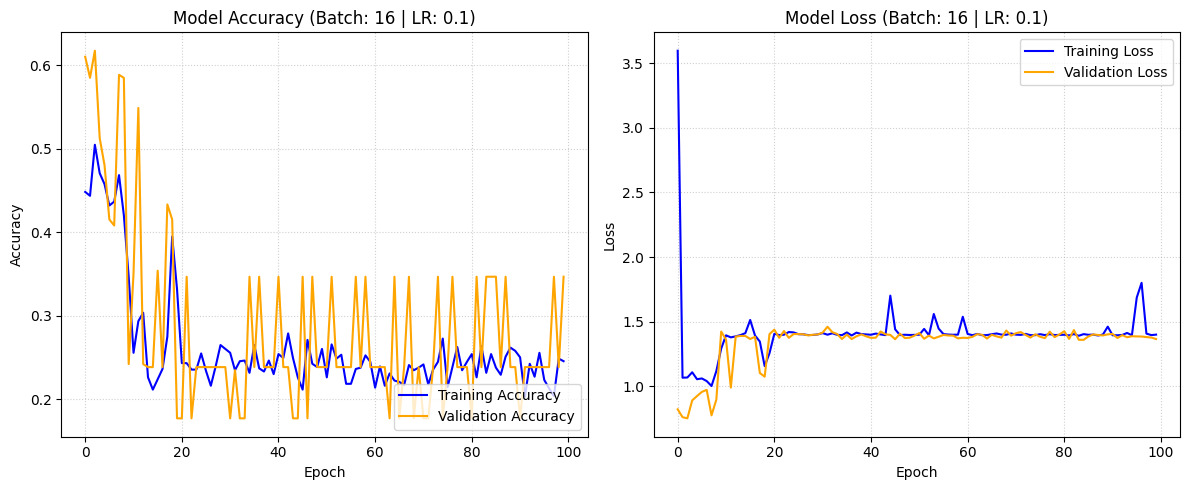

  -> Training Model | Learning Rate: 0.01 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9567 (Reached at Epoch 100)
     [Plot Saved] -> Stage1_Batch_16_LR_0.01.png


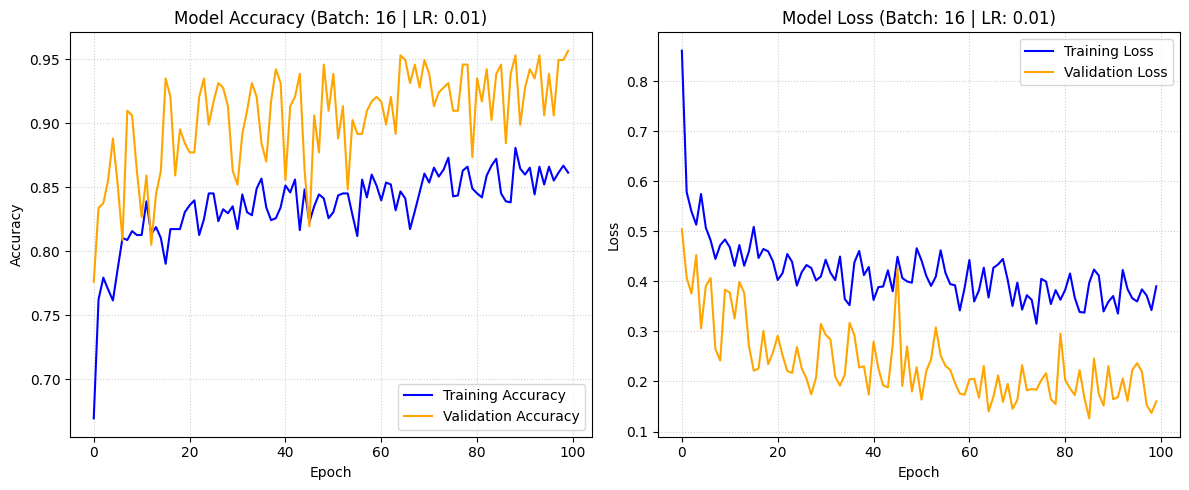

  -> Training Model | Learning Rate: 0.001 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9783 (Reached at Epoch 77)
     [Plot Saved] -> Stage1_Batch_16_LR_0.001.png


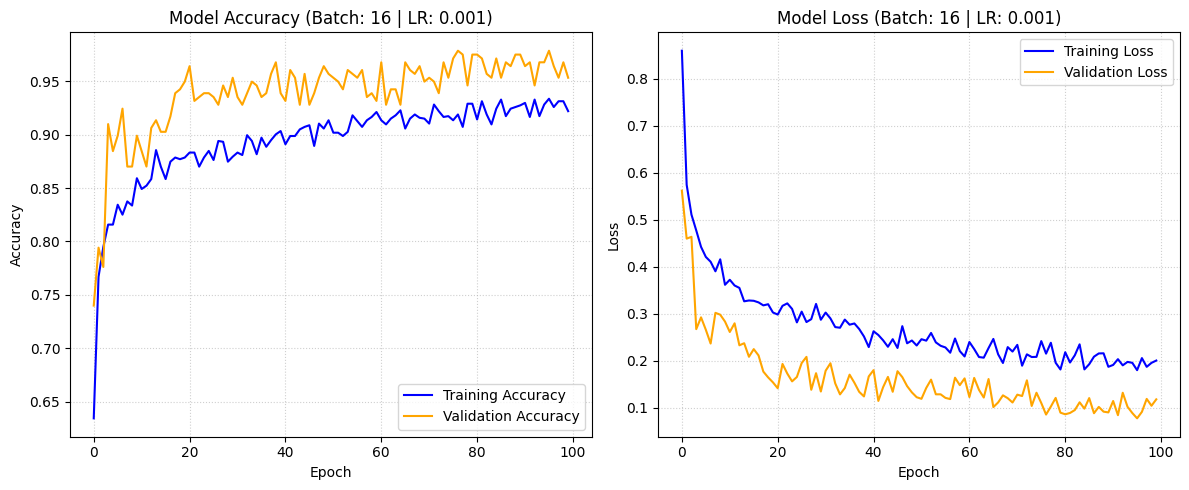

  -> Training Model | Learning Rate: 0.0001 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9711 (Reached at Epoch 90)
     [Plot Saved] -> Stage1_Batch_16_LR_0.0001.png


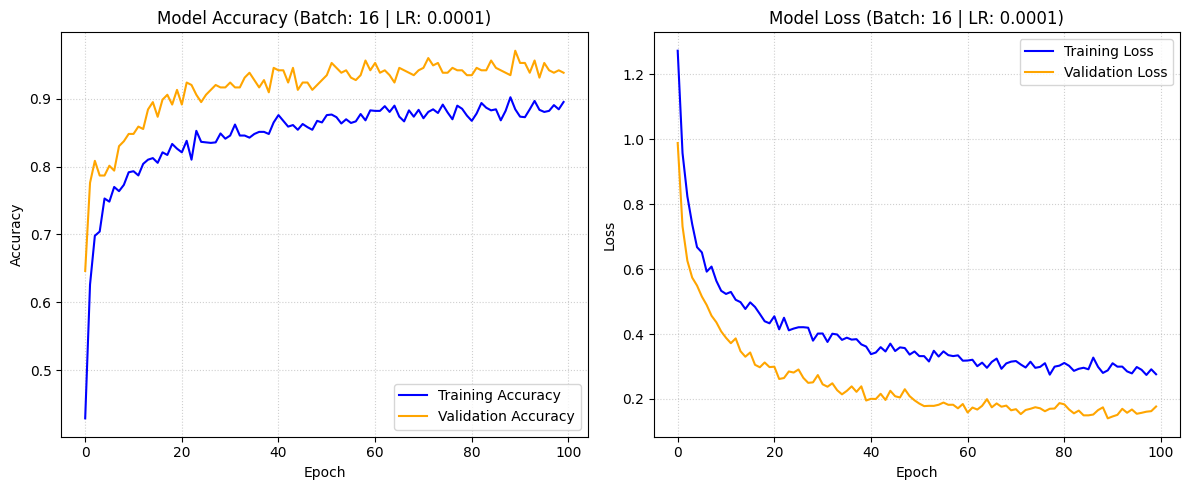

  -> Training Model | Learning Rate: 1e-05 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.8809 (Reached at Epoch 100)
     [Plot Saved] -> Stage1_Batch_16_LR_1e-05.png


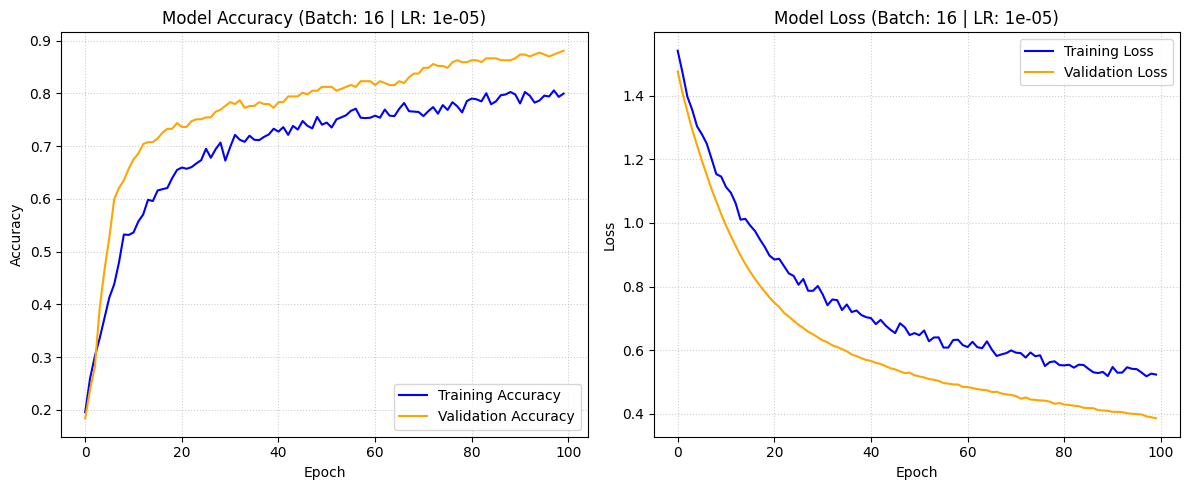


[Data Setup] Configuring Generator for Batch Size: 32
  -> Training Model | Learning Rate: 0.1 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.3502 (Reached at Epoch 25)
     [Plot Saved] -> Stage1_Batch_32_LR_0.1.png


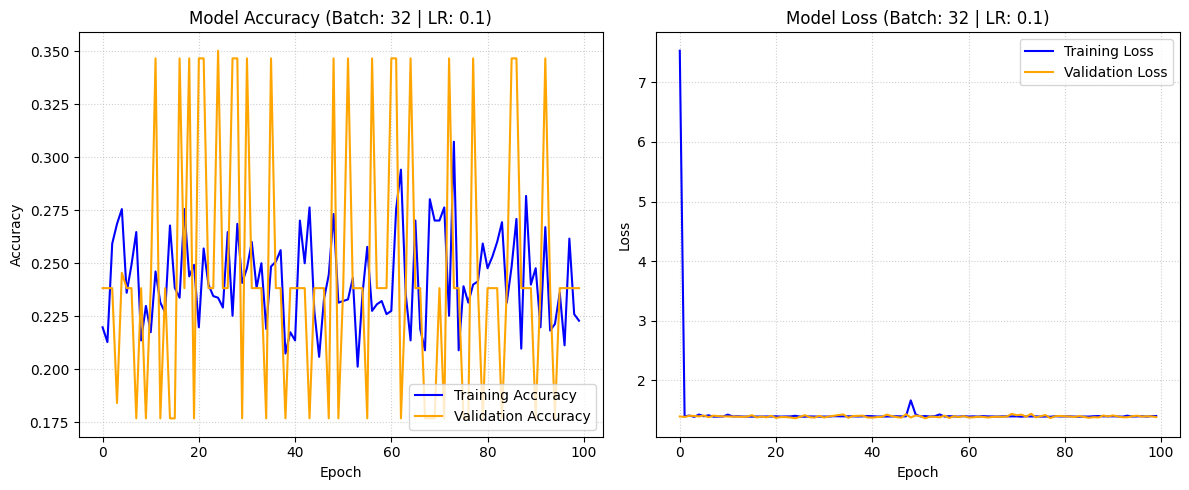

  -> Training Model | Learning Rate: 0.01 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9567 (Reached at Epoch 61)
     [Plot Saved] -> Stage1_Batch_32_LR_0.01.png


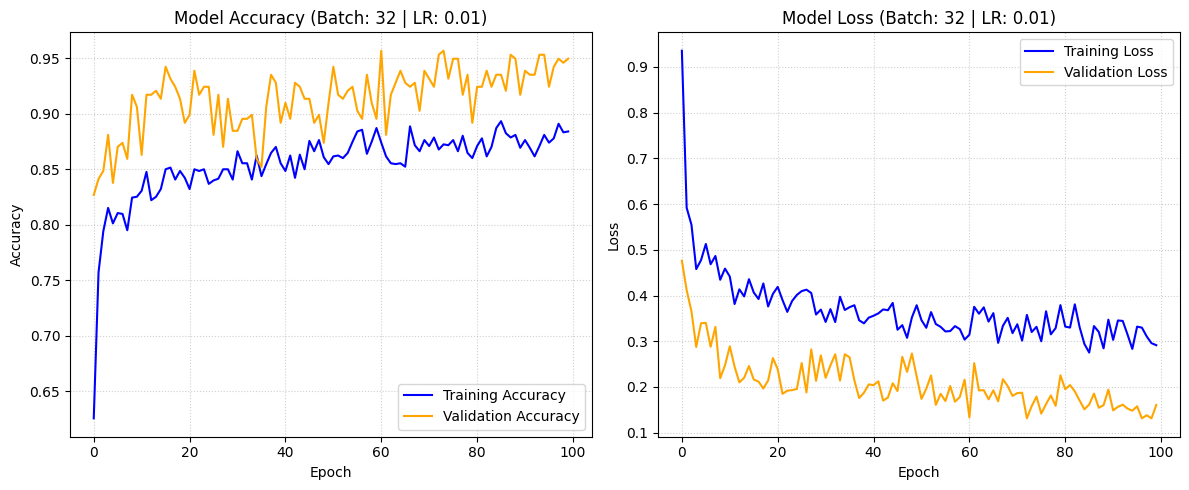

  -> Training Model | Learning Rate: 0.001 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9747 (Reached at Epoch 84)
     [Plot Saved] -> Stage1_Batch_32_LR_0.001.png


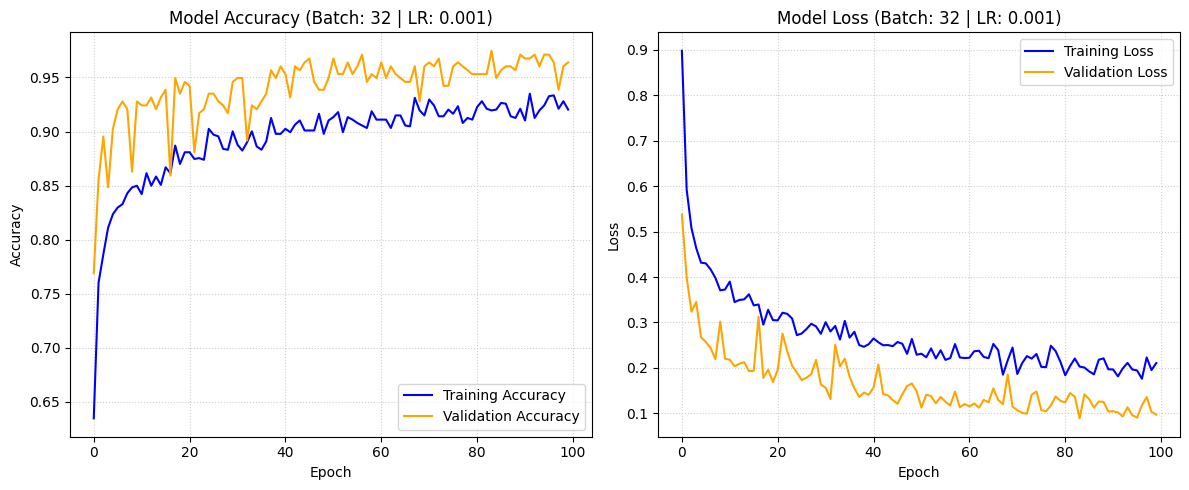

  -> Training Model | Learning Rate: 0.0001 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.9458 (Reached at Epoch 97)
     [Plot Saved] -> Stage1_Batch_32_LR_0.0001.png


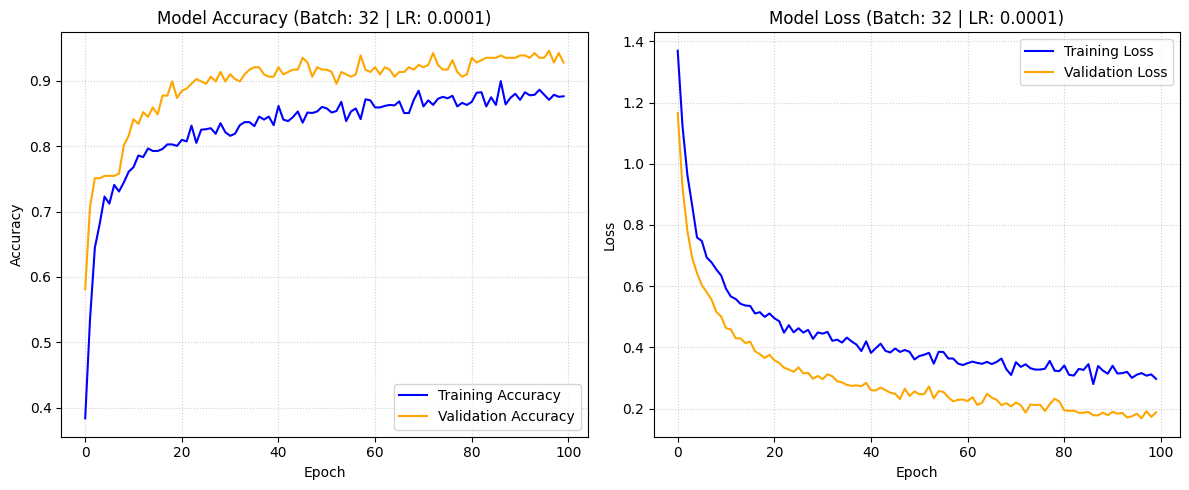

  -> Training Model | Learning Rate: 1e-05 (100 Epochs)...
     Finished! Peak Val Accuracy: 0.8267 (Reached at Epoch 100)
     [Plot Saved] -> Stage1_Batch_32_LR_1e-05.png


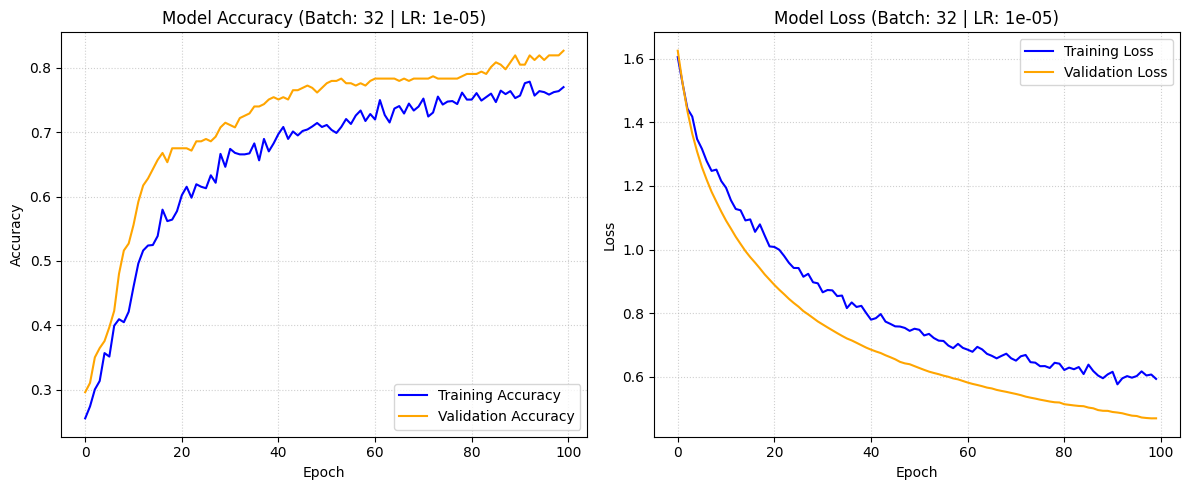


=== ALL EVALUATIONS COMPLETED ===

Summary of Full Trajectory Exploration (10 Scenarios):
 Batch Size  Learning Rate  Peak Val Accuracy  Peak Epoch  Lowest Val Loss
         16        0.10000           0.617329           3         0.751444
         16        0.01000           0.956679         100         0.126315
         16        0.00100           0.978339          77         0.077939
         16        0.00010           0.971119          90         0.140419
         16        0.00001           0.880866         100         0.385608
         32        0.10000           0.350181          25         1.362972
         32        0.01000           0.956679          61         0.131322
         32        0.00100           0.974729          84         0.089006
         32        0.00010           0.945848          97         0.168040
         32        0.00001           0.826715         100         0.469437


In [ ]:
import gc
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

# 1. Parameter Grid Search
batch_sizes = [16, 32]
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]

# Tempat menyimpan catatan hasil evaluasi dari sepuluh skenario
experiment_results = []

print("=== STARTING STAGE 1: FULL TRAJECTORY EXPLORATION ===")

# 2. Perulangan Luar untuk Ukuran Kelompok Data (Batch Size)
for batch_size in batch_sizes:
    print(f"\n[Data Setup] Configuring Generator for Batch Size: {batch_size}")
    
    # Membangun ulang generator data sesuai ukuran kelompok saat ini
    # Pastikan datagen_latih dan datagen_valid_uji menggunakan nama variabel Anda yang sesuai
    train_gen = datagen_latih.flow(X_latih, y_latih, batch_size=batch_size)
    val_gen = datagen_valid_uji.flow(X_valid, y_valid, batch_size=batch_size, shuffle=False)
    
    # 3. Perulangan Dalam untuk Laju Pembelajaran (Learning Rate)
    for lr in learning_rates:
        print(f"  -> Training Model | Learning Rate: {lr} (100 Epochs)...")
        
        # A. Membersihkan memori sistem dasar secara ekstrem
        tf.keras.backend.clear_session()
        
        # B. Membangun arsitektur model dari titik awal
        base_model = EfficientNetV2B0(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3))
        
        base_model.trainable = False
        
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.2),
            Dense(4, activation='softmax')
        ])
        
        # C. Melakukan kompilasi dengan algoritma Adam
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # D. Mengeksekusi pelatihan TANPA fungsi penghenti dini (100 Epochs)
        history = model.fit(
            train_gen,
            epochs=100,
            validation_data=val_gen,
            class_weight=kamus_bobot, # Pastikan variabel kamus_bobot sudah ada
            verbose=0 # Layar dibisukan agar terminal tidak penuh teks
        )
        
        # E. Mencari catatan akurasi tertinggi dan pada putaran ke berapa ia terjadi
        val_accuracies = history.history['val_accuracy']
        peak_val_acc = max(val_accuracies)
        peak_epoch = val_accuracies.index(peak_val_acc) + 1
        lowest_val_loss = min(history.history['val_loss'])
        
        print(f"     Finished! Peak Val Accuracy: {peak_val_acc:.4f} (Reached at Epoch {peak_epoch})")
        
        # F. Membuat dan menyimpan grafik evaluasi (Semua dalam Bahasa Inggris)
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs_range = range(len(acc))

        plt.figure(figsize=(12, 5))

        # Grafik Akurasi (Training vs Validation Accuracy)
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
        plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
        plt.title(f'Model Accuracy (Batch: {batch_size} | LR: {lr})')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(loc='lower right')
        plt.grid(True, linestyle=':', alpha=0.6)

        # Grafik Kerugian (Training vs Validation Loss)
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label='Training Loss', color='blue')
        plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
        plt.title(f'Model Loss (Batch: {batch_size} | LR: {lr})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        
        # Menyimpan gambar
        filename = f"Stage1_Batch_{batch_size}_LR_{lr}.png"
        plt.savefig(filename, dpi=300)
        print(f"     [Plot Saved] -> {filename}")
        
        # Menampilkan gambar sementara di layar
        plt.show()
        plt.close()
        
        # G. Menyimpan hasil numerik ke dalam tabel rekap
        experiment_results.append({
            'Batch Size': batch_size,
            'Learning Rate': lr,
            'Peak Val Accuracy': peak_val_acc,
            'Peak Epoch': peak_epoch,
            'Lowest Val Loss': lowest_val_loss
        })
        
        # H. Penghapusan model untuk mengosongkan memori kartu grafis
        del model
        del base_model
        gc.collect()

print("\n=== ALL EVALUATIONS COMPLETED ===")

# 4. Mencetak tabel hasil akhir menggunakan Pandas
results_df = pd.DataFrame(experiment_results)
print("\nSummary of Full Trajectory Exploration (10 Scenarios):")
print(results_df.to_string(index=False))

## Melatih Ulang Setelah Pengujian Prameter

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

print("=== MEMULAI PELATIHAN FINAL (TAHAP KEDUA) ===")

# 1. Kunci parameter pemenang dari hasil eksperimen sebelumnya
batch_size_terbaik = 16
learning_rate_terbaik = 0.001

# 2. Siapkan ulang generator data dengan batch size pemenang
# Pastikan variabel datagen_latih, datagen_valid_uji, X, dan y sesuai
gen_latih_final = datagen_latih.flow(X_latih, y_latih, batch_size=batch_size_terbaik)
gen_valid_final = datagen_valid_uji.flow(X_valid, y_valid, batch_size=batch_size_terbaik, shuffle=False)

# 3. Bersihkan sisa memori komputasi sebelumnya agar tidak terjadi kebocoran memori (Out of Memory)
tf.keras.backend.clear_session()

# 4. Bangun ulang arsitektur model dari awal (Mesin baru yang bersih)
model_dasar = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_dasar.trainable = False

model_final = Sequential([
    model_dasar,
    GlobalAveragePooling2D(),
    Dropout(0.3), # Regularisasi pertama
    Dense(128, activation='relu'), # Lapisan tersembunyi
    Dropout(0.2), # Regularisasi kedua
    Dense(4, activation='softmax')
])

# 5. Kompilasi model dengan Learning Rate terbaik
model_final.compile(
    optimizer=Adam(learning_rate=learning_rate_terbaik),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. MENGAKTIFKAN KEMBALI PENGAWAS HENTI DINI (Early Stopping)
# Kita atur batas kesabaran (patience) 10 putaran
pengawas_henti_dini = EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True, # Mengembalikan bobot terbaik secara otomatis
    verbose=1 
)

# 7. Eksekusi Pelatihan
print("Melatih model final. Sistem akan berhenti otomatis saat performa puncak tercapai...")
riwayat_final = model_final.fit(
    gen_latih_final,
    epochs=100, # Biarkan 100, karena Early Stopping akan memotongnya di tengah jalan
    validation_data=gen_valid_final,
    class_weight=kamus_bobot, # Masukkan hasil perhitungan bobot data yang imbalance tadi
    callbacks=[pengawas_henti_dini] # Ini yang paling penting!
)

# 8. Menyimpan Model sebagai file h5
model_final.save("Model_EfficientNetV2B0_Final.h5")
print("\n=== PELATIHAN FINAL SELESAI. MODEL BERHASIL DISIMPAN! ===")

=== MEMULAI PELATIHAN FINAL (TAHAP KEDUA) ===
Melatih model final. Sistem akan berhenti otomatis saat performa puncak tercapai...
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 903ms/step - accuracy: 0.6440 - loss: 0.8432 - val_accuracy: 0.7184 - val_loss: 0.6008
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 52s 638ms/step - accuracy: 0.7469 - loss: 0.5941 - val_accuracy: 0.8448 - val_loss: 0.3756
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7895 - loss: 0.5143 - val_accuracy: 0.8267 - val_loss: 0.4540
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 88s 467ms/step - accuracy: 0.8104 - loss: 0.4922 - val_accuracy: 0.8809 - val_loss: 0.3246
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 32s 389ms/step - accuracy: 0.8297 - loss: 0.4397 - val_accuracy: 0.9025 - val_loss: 0.2711
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 400ms/step - accuracy: 0.8320 - loss: 0.4196 - val_accuracy: 0.8520 - val_loss: 0.3494
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 31s 382ms/step - accuracy: 0.8344 - loss: 0.4242 - va


=== PELATIHAN FINAL SELESAI. MODEL BERHASIL DISIMPAN! ===


## Grafik Hasil Training

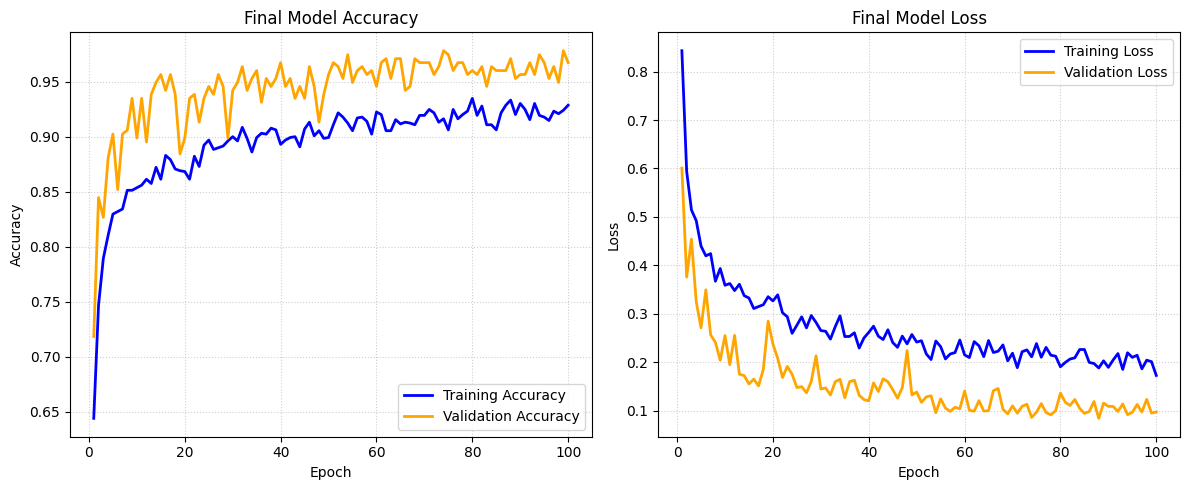

In [ ]:
import matplotlib.pyplot as plt

# Mengekstraksi data riwayat dari variabel pelatihan final
akurasi = riwayat_final.history['accuracy']
val_akurasi = riwayat_final.history['val_accuracy']
kerugian = riwayat_final.history['loss']
val_kerugian = riwayat_final.history['val_loss']

# Menentukan rentang sumbu X berdasarkan jumlah putaran aktual
rentang_putaran = range(1, len(akurasi) + 1)

# Membuat kanvas visualisasi berukuran 12x5 inci
plt.figure(figsize=(12, 5))

# Menggambar Kurva Akurasi
plt.subplot(1, 2, 1)
plt.plot(rentang_putaran, akurasi, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(rentang_putaran, val_akurasi, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Final Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Menggambar Kurva Kerugian
plt.subplot(1, 2, 2)
plt.plot(rentang_putaran, kerugian, label='Training Loss', color='blue', linewidth=2)
plt.plot(rentang_putaran, val_kerugian, label='Validation Loss', color='orange', linewidth=2)
plt.title('Final Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Merapikan tata letak dan menyimpan gambar
plt.tight_layout()
plt.savefig("Grafik_Pelatihan_Final.png", dpi=300)
plt.show()

## Evaluasi

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step


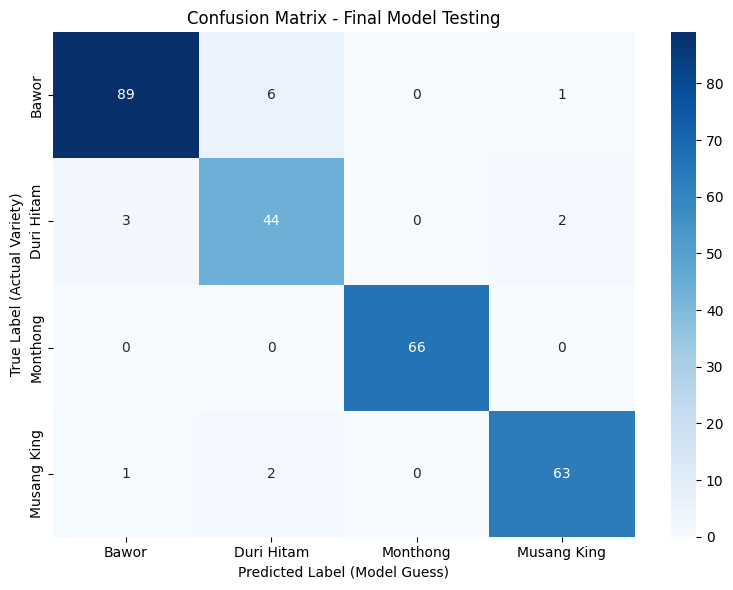


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       Bawor       0.96      0.93      0.94        96
  Duri Hitam       0.85      0.90      0.87        49
    Monthong       1.00      1.00      1.00        66
 Musang King       0.95      0.95      0.95        66

    accuracy                           0.95       277
   macro avg       0.94      0.94      0.94       277
weighted avg       0.95      0.95      0.95       277



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

# 1. Memuat otak arsitektur final yang telah lulus pelatihan
model_final = tf.keras.models.load_model("Model_EfficientNetV2B0_Final.h5")

# 2. Menyiapkan aliran data uji
# Parameter shuffle WAJIB bernilai False agar urutan tebakan tidak berantakan
gen_uji = datagen_valid_uji.flow(X_uji, y_uji, batch_size=16, shuffle=False)

# 3. Memerintahkan sistem untuk menebak seluruh citra uji
prediksi_probabilitas = model_final.predict(gen_uji)

# Mengonversi nilai probabilitas tebakan menjadi indeks kelas pasti
prediksi_kelas = np.argmax(prediksi_probabilitas, axis=1)
label_asli = np.argmax(y_uji, axis=1)

# 4. Mendefinisikan label kelas sesuai urutan alfabetis sistem
nama_kelas = ['Bawor', 'Duri Hitam', 'Monthong', 'Musang King']

# 5. Membangun visualisasi Matriks Kebingungan
matriks = confusion_matrix(label_asli, prediksi_kelas)

plt.figure(figsize=(8, 6))
sns.heatmap(matriks, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nama_kelas, yticklabels=nama_kelas)

plt.title('Confusion Matrix - Final Model Testing')
plt.ylabel('True Label (Actual Variety)')
plt.xlabel('Predicted Label (Model Guess)')
plt.tight_layout()

# Menyimpan hasil visualisasi matriks kebingungan
plt.savefig("Matriks_Kebingungan_Final.png", dpi=300)
plt.show()

# 6. Mencetak laporan metrik klasifikasi akhir
print("\n=== CLASSIFICATION REPORT ===")
laporan_metrik = classification_report(label_asli, prediksi_kelas, target_names=nama_kelas)
print(laporan_metrik)

## Model CNN

In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Rescaling, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

print("=== TAHAP 1: MEMBANGUN ARSITEKTUR CNN DARI AWAL ===")

# Bersihkan sisa memori sebelumnya agar alokasi RAM bersih
tf.keras.backend.clear_session()

# Membangun arsitektur CNN dasar secara sekuensial (Sesuai Kode 4.3)
model_cnn_dasar = Sequential([
    Rescaling(1./255, input_shape=(224, 224, 3)),

    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), 
    Dense(4, activation='softmax')
])

print("Arsitektur CNN berhasil dibangun!")

print("\n=== TAHAP 2: MEMULAI PELATIHAN MODEL CNN PEMBANDING ===")

# Kompilasi model dengan parameter kontrol yang sama persis
model_cnn_dasar.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mengaktifkan pengawas henti dini dengan batas kesabaran sepuluh putaran
pengawas_henti_dini_cnn = EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True,
    verbose=1 
)

# Mengeksekusi pelatihan menggunakan data latih dan bobot penyeimbang
riwayat_cnn = model_cnn_dasar.fit(
    gen_latih_final, # Pastikan variabel ini sudah tereksekusi sebelumnya
    epochs=100,
    validation_data=gen_valid_final, # Pastikan variabel ini juga sudah ada
    class_weight=kamus_bobot, # Pastikan variabel bobot kelas ini masih ada di memori
    callbacks=[pengawas_henti_dini_cnn]
)

print("\n=== TAHAP 3: PENGUJIAN FINAL MODEL CNN PEMBANDING ===")

# Melakukan prediksi pada data uji yang belum pernah dilihat model
prediksi_probabilitas_cnn = model_cnn_dasar.predict(gen_uji)
prediksi_kelas_cnn = np.argmax(prediksi_probabilitas_cnn, axis=1)
label_asli_cnn = np.argmax(y_uji, axis=1)

# Mencetak laporan klasifikasi metrik model pembanding
nama_kelas = ['Bawor', 'Duri Hitam', 'Monthong', 'Musang King']
laporan_cnn = classification_report(label_asli_cnn, prediksi_kelas_cnn, target_names=nama_kelas)
print(laporan_cnn)

=== TAHAP 1: MEMBANGUN ARSITEKTUR CNN DARI AWAL ===
Arsitektur CNN berhasil dibangun!

=== TAHAP 2: MEMULAI PELATIHAN MODEL CNN PEMBANDING ===


d:\CODING\Durian Leaf Classification\env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\CODING\Durian Leaf Classification\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.3738 - loss: 1.4026 - val_accuracy: 0.4585 - val_loss: 1.1504
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 68s 844ms/step - accuracy: 0.4342 - loss: 1.2739 - val_accuracy: 0.5235 - val_loss: 1.1421
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 884ms/step - accuracy: 0.5077 - loss: 1.1903 - val_accuracy: 0.5523 - val_loss: 1.0987
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 896ms/step - accuracy: 0.5147 - loss: 1.1487 - val_accuracy: 0.5668 - val_loss: 1.0571
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 897ms/step - accuracy: 0.5132 - loss: 1.1394 - val_accuracy: 0.5487 - val_loss: 1.1020
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 71s 756ms/step - accuracy: 0.5085 - loss: 1.1104 - val_accuracy: 0.4874 - val_loss: 1.1209
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5372 - loss: 1.0855 - val_accuracy: 0.5848 - val_loss: 0.9704
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.5534 - loss: 1.0556 - val_accu

## Grafik CNN

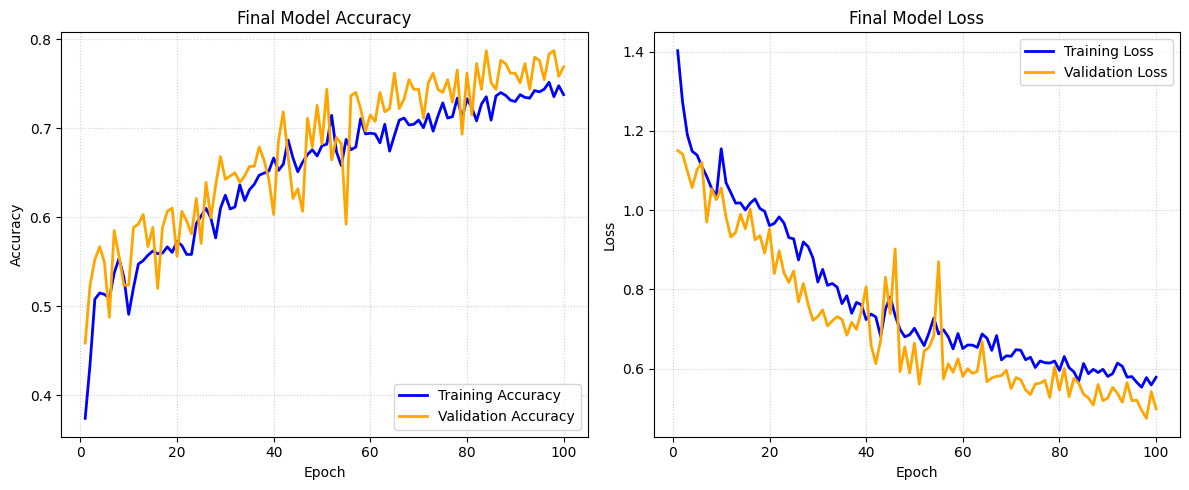

In [22]:
import matplotlib.pyplot as plt

# Mengekstraksi data riwayat dari variabel pelatihan final
akurasi = riwayat_cnn.history['accuracy']
val_akurasi = riwayat_cnn.history['val_accuracy']
kerugian = riwayat_cnn.history['loss']
val_kerugian = riwayat_cnn.history['val_loss']

# Menentukan rentang sumbu X berdasarkan jumlah putaran aktual
rentang_putaran = range(1, len(akurasi) + 1)

# Membuat kanvas visualisasi berukuran 12x5 inci
plt.figure(figsize=(12, 5))

# Menggambar Kurva Akurasi
plt.subplot(1, 2, 1)
plt.plot(rentang_putaran, akurasi, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(rentang_putaran, val_akurasi, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Final Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Menggambar Kurva Kerugian
plt.subplot(1, 2, 2)
plt.plot(rentang_putaran, kerugian, label='Training Loss', color='blue', linewidth=2)
plt.plot(rentang_putaran, val_kerugian, label='Validation Loss', color='orange', linewidth=2)
plt.title('Final Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Merapikan tata letak dan menyimpan gambar
plt.tight_layout()
plt.savefig("Grafik_Pelatihan_Final.png", dpi=300)
plt.show()

In [24]:
model_cnn_dasar.save("Model_Baseline_CNN_Final.h5")

## Evaluasi

=== MEMULAI EVALUASI FINAL PADA DATA UJI ===

Memuat dan mengevaluasi Baseline CNN...


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step

--- HASIL METRIK BASELINE CNN ---
Varietas        | Precision  | Recall     | Support   
-------------------------------------------------------
Bawor           | 0.86       | 0.71       | 96        
Duri Hitam      | 0.49       | 0.65       | 49        
Monthong        | 0.99       | 1.00       | 66        
Musang King     | 0.68       | 0.68       | 66        
-------------------------------------------------------
Macro Average   | 0.75       | 0.76       | 277       
-------------------------------------------------------


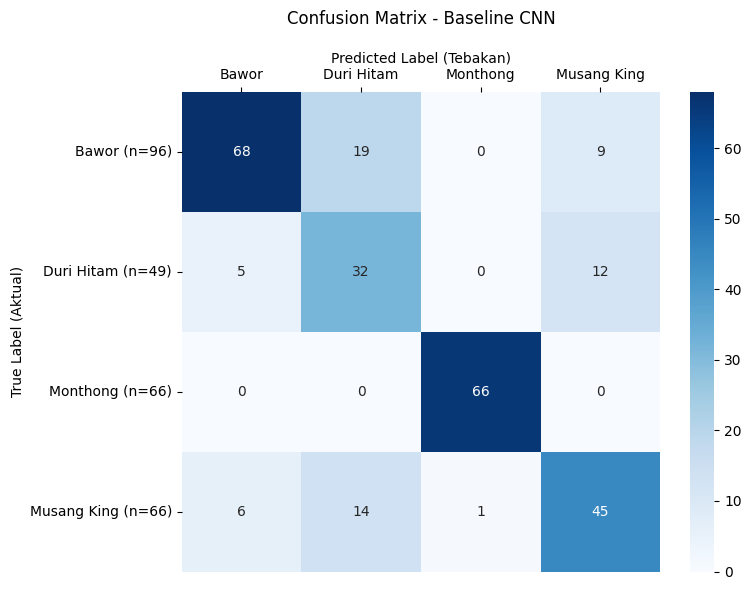


Memuat dan mengevaluasi EfficientNetV2 B0...


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step

--- HASIL METRIK EFFICIENTNETV2 B0 ---
Varietas        | Precision  | Recall     | Support   
-------------------------------------------------------
Bawor           | 0.96       | 0.93       | 96        
Duri Hitam      | 0.85       | 0.90       | 49        
Monthong        | 1.00       | 1.00       | 66        
Musang King     | 0.95       | 0.95       | 66        
-------------------------------------------------------
Macro Average   | 0.94       | 0.94       | 277       
-------------------------------------------------------


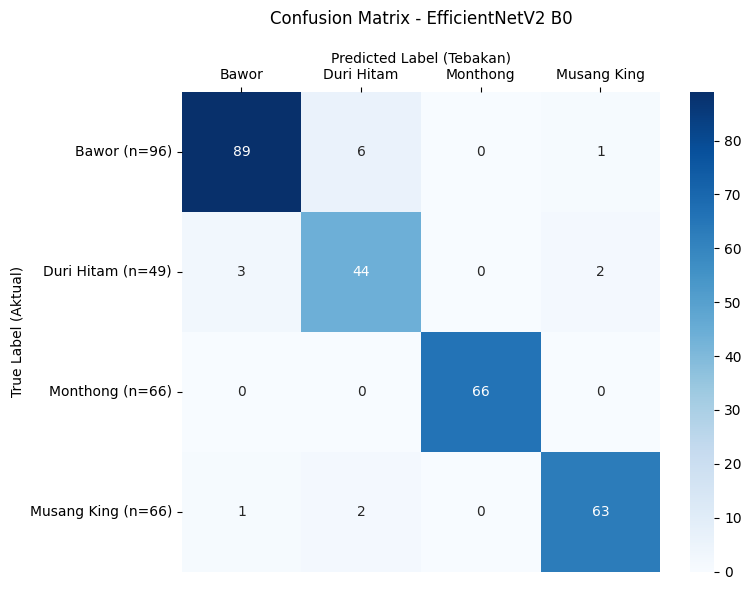

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

print("=== MEMULAI EVALUASI FINAL PADA DATA UJI ===")

# Mendefinisikan label kelas sesuai urutan alfabetis sistem
nama_kelas = ['Bawor', 'Duri Hitam', 'Monthong', 'Musang King']

# Menyiapkan aliran data uji tanpa pengacakan (shuffle mutlak False)
gen_uji = datagen_valid_uji.flow(X_uji, y_uji, batch_size=16, shuffle=False)
label_asli = np.argmax(y_uji, axis=1)

# Fungsi khusus untuk mengevaluasi dan mencetak hasil model
def evaluasi_model_final(nama_file, nama_arsitektur):
    print(f"\nMemuat dan mengevaluasi {nama_arsitektur}...")
    model = tf.keras.models.load_model(nama_file)
    
    # Memerintahkan sistem untuk menebak seluruh citra uji
    prediksi_probabilitas = model.predict(gen_uji)
    prediksi_kelas = np.argmax(prediksi_probabilitas, axis=1)
    
    # Mengekstrak metrik presisi rekal dan support untuk setiap kelas individual
    presisi, rekal, f1, support = precision_recall_fscore_support(label_asli, prediksi_kelas, average=None)
    
    # INSTRUKSI BARU: Menghitung nilai rata rata makro (Macro Average) dan total data
    presisi_makro = np.mean(presisi)
    rekal_makro = np.mean(rekal)
    total_support = np.sum(support)
    
    # Mencetak laporan metrik dalam bentuk tabel tabular yang rapi
    print(f"\n--- HASIL METRIK {nama_arsitektur.upper()} ---")
    print(f"{'Varietas':<15} | {'Precision':<10} | {'Recall':<10} | {'Support':<10}")
    print("-" * 55)
    
    # Mencetak baris untuk masing masing kelas
    for i in range(len(nama_kelas)):
        print(f"{nama_kelas[i]:<15} | {presisi[i]:<10.2f} | {rekal[i]:<10.2f} | {support[i]:<10}")
        
    # INSTRUKSI BARU: Mencetak baris tambahan untuk Macro Average di paling bawah tabel
    print("-" * 55)
    print(f"{'Macro Average':<15} | {presisi_makro:<10.2f} | {rekal_makro:<10.2f} | {total_support:<10}")
    print("-" * 55)
        
    # Membangun visualisasi Matriks Kebingungan
    matriks = confusion_matrix(label_asli, prediksi_kelas)
    
    # Memperbesar ukuran kanvas agar teks tambahan tidak terpotong
    plt.figure(figsize=(8, 6))
    
    # # Menggabungkan nama kelas dengan angka support untuk label sumbu Y (kiri)
    # label_y_dengan_jumlah = [f"{nama_kelas[i]} (n={support[i]})" for i in range(len(nama_kelas))]
    
    # Membangun matriks dengan memisahkan label X dan Y
    ax = sns.heatmap(matriks, annot=True, fmt='d', cmap='Blues', 
                     xticklabels=nama_kelas, yticklabels=label_y_dengan_jumlah)
    
    # Memindahkan posisi label sumbu X ke bagian atas
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # Menambahkan bantalan pad=20 agar judul tidak menabrak label atas
    plt.title(f'Confusion Matrix - {nama_arsitektur}', pad=20)
    plt.ylabel('True Label (Aktual)')
    plt.xlabel('Predicted Label (Tebakan)')
    
    # Mengatur tata letak agar proporsional sebelum disimpan
    plt.tight_layout()
    plt.savefig(f"Matriks_Kebingungan_{nama_arsitektur.replace(' ', '_')}.png", dpi=300)
    plt.show()

# Mengeksekusi fungsi evaluasi untuk kedua model secara berurutan
evaluasi_model_final("Model_Baseline_CNN_Final.h5", "Baseline CNN")
evaluasi_model_final("Model_EfficientNetV2B0_Final.h5", "EfficientNetV2 B0")